let's load up a cleaned version of romeo + juliet

and then plot the validation data from david bamman

In [2]:
import json
import matplotlib.pyplot as plt
%matplotlib inline
import re

In [10]:
f = open("full.html","r")
act = 0
total_scenes = 0
for line in f:
    x = re.findall(r"<H3>([A-Z ]+)</h3>",line)
    if x:
        print(x[0])
        act+=1
        scene = 0
    # will only match the prologue
    x = re.findall(r"<h3>([A-Z ]+)</h3>",line)
    # will also get the scenes
    y = re.findall(r"<h3>([A-Za-z\.\'\; ]+)</h3>",line)
    if y:
        print(y[0])
        total_scenes+=1
        scene+=1
f.close()

ACT I
PROLOGUE
SCENE I. Verona. A public place.
SCENE II. A street.
SCENE III. A room in Capulet's house.
SCENE IV. A street.
SCENE V. A hall in Capulet's house.
ACT II
PROLOGUE
SCENE I. A lane by the wall of Capulet's orchard.
SCENE II. Capulet's orchard.
SCENE III. Friar Laurence's cell.
SCENE IV. A street.
SCENE V. Capulet's orchard.
SCENE VI. Friar Laurence's cell.
ACT III
SCENE I. A public place.
SCENE II. Capulet's orchard.
SCENE III. Friar Laurence's cell.
SCENE IV. A room in Capulet's house.
SCENE V. Capulet's orchard.
ACT IV
SCENE I. Friar Laurence's cell.
SCENE II. Hall in Capulet's house.
SCENE III. Juliet's chamber.
SCENE IV. Hall in Capulet's house.
SCENE V. Juliet's chamber.
ACT V
SCENE I. Mantua. A street.
SCENE II. Friar Laurence's cell.
SCENE III. A churchyard; in it a tomb belonging to the Capulets.


In [11]:
total_scenes

26

In [27]:
f = open("full.html","r")
act = 0
data = []
for line in f:
    x = re.findall(r"<H3>([A-Z ]+)</h3>",line)
    if x:
        act+=1
        data.append([])
        scene = 0
    y = re.findall(r"<h3>([A-Za-z\.\'\; ]+)</h3>",line)
    if y:
        data[act-1].append([])
        total_scenes+=1
        scene+=1
        speaker = "Narrator"
    x = re.findall(r"<A NAME=speech([0-9]+)><b>(.*?)</b></a>",line)
    if x:
        # print(x[0][0])
        speaker = x[0][1]
    x = re.findall(r"<A NAME=([0-9]+).([0-9]+).([0-9]+)>(.*?)</A>",line)
    if x:
        # print(x)
        matched_act = int(x[0][0])
        matched_scene = int(x[0][1])
        matched_line = int(x[0][2])
        data[act-1][scene-1].append([x[0][3],speaker])
f.close()

In [28]:
data[0]

[[['Two households, both alike in dignity,', 'Narrator'],
  ['In fair Verona, where we lay our scene,', 'Narrator'],
  ['From ancient grudge break to new mutiny,', 'Narrator'],
  ['Where civil blood makes civil hands unclean.', 'Narrator'],
  ['From forth the fatal loins of these two foes', 'Narrator'],
  ["A pair of star-cross'd lovers take their life;", 'Narrator'],
  ['Whose misadventured piteous overthrows', 'Narrator'],
  ["Do with their death bury their parents' strife.", 'Narrator'],
  ["The fearful passage of their death-mark'd love,", 'Narrator'],
  ["And the continuance of their parents' rage,", 'Narrator'],
  ["Which, but their children's end, nought could remove,", 'Narrator'],
  ["Is now the two hours' traffic of our stage;", 'Narrator'],
  ['The which if you with patient ears attend,', 'Narrator'],
  ['What here shall miss, our toil shall strive to mend.', 'Narrator']],
 [["Gregory, o' my word, we'll not carry coals.", 'SAMPSON'],
  ['No, for then we should be colliers.',

In [32]:
scene_lengths = [[len(scene) for scene in act] for act in data]

In [33]:
scene_lengths

[[14, 238, 103, 110, 120, 154],
 [14, 45, 204, 97, 208, 80, 37],
 [203, 147, 179, 37, 255],
 [127, 48, 59, 31, 142],
 [90, 30, 321]]

In [37]:
scene_word_lengths = [[sum([len(line[0].split(" ")) for line in scene]) for scene in act] for act in data]

In [38]:
scene_word_lengths

[[106, 1821, 789, 890, 919, 1199],
 [113, 361, 1609, 753, 1624, 669, 291],
 [1569, 1125, 1377, 297, 2031],
 [1030, 364, 468, 225, 1099],
 [724, 222, 2508]]

In [39]:
flat_scene_word_lengths = [sum([len(line[0].split(" ")) for line in scene])for act in data for scene in act]

In [40]:
flat_scene_word_lengths

[106,
 1821,
 789,
 890,
 919,
 1199,
 113,
 361,
 1609,
 753,
 1624,
 669,
 291,
 1569,
 1125,
 1377,
 297,
 2031,
 1030,
 364,
 468,
 225,
 1099,
 724,
 222,
 2508]

In [43]:
total_words = sum(flat_scene_word_lengths)

In [44]:
print(total_words)

24183


now let's rate this using our algorithm

In [46]:
import sys
sys.path.append("/Users/andyreagan/tools/python")
from kitchentable.dogtoys import *
from labMTsimple.labMTsimple.speedy import LabMT
my_LabMT = LabMT()
from labMTsimple.labMTsimple.storyLab import *
import numpy as np
import pickle

In [47]:
f = open("full.p","wb")
f.write(pickle.dumps(data))
f.close()

In [49]:
all_word_list = " ".join([" ".join([line[0] for line in scene]) for act in data for scene in act])

In [51]:
all_word_list[:500]

"Two households, both alike in dignity, In fair Verona, where we lay our scene, From ancient grudge break to new mutiny, Where civil blood makes civil hands unclean. From forth the fatal loins of these two foes A pair of star-cross'd lovers take their life; Whose misadventured piteous overthrows Do with their death bury their parents' strife. The fearful passage of their death-mark'd love, And the continuance of their parents' rage, Which, but their children's end, nought could remove, Is now the"

In [59]:
from scipy.sparse import lil_matrix,issparse
from numpy import floor,dot

In [60]:
def chopper_sliding(all_word_list,my_senti_dict,min_size=10000,num_points=100,stop_val=0.0):
    """Take long piece of text and generate the sentiment time series.
    We will now slide the window along, rather than make uniform pieces.

    If the pickle of the timeseries and the sentiment vectors both exist, it will load and return these.
    If only the sentiment vectors exist, it will use these to make the timeseries specified.
    If neither exists, it will save both.

    If fvec_preloaded, won't return the window centers, since it never touches the raw text file.
    We don't touch it, because that's a costly procedure, to re-tokenize everything.
    """

    all_fvecs = lil_matrix((200,10222),dtype="i")
    word_list = all_word_list
    # first, just build the matrix
    step = int(floor((len(word_list)-min_size)/(num_points-1)))
    # print("there are "+str(len(self.all_word_list))+" words in the book")
    # print("step size "+str(step))
    centers = [i*step+(min_size)/2 for i in range(num_points)]
    for i in range(num_points-1):
        window_dict = dict()
        # print("using words {} through {}".format(i*step,min_size+i*step))
        for word in word_list[(i*step):(min_size+i*step)]:
            if word in window_dict:
                window_dict[word] += 1
            else:
                window_dict[word] = 1
        text_fvec = my_senti_dict.wordVecify(window_dict)
        all_fvecs[i,:] = text_fvec
    i = num_points-1
    window_dict = dict()
    # print("using words {} through {}".format(i*step,len(all_words)))
    for word in word_list[(i*step):]:
        if word in window_dict:
            window_dict[word] += 1
        else: 
            window_dict[word] = 1
    text_fvec = my_senti_dict.wordVecify(window_dict)
    all_fvecs[i,:] = text_fvec
    all_fvecs = all_fvecs.tocsr()

    # all_fvecs_stopped = stopper_mat(self.all_fvecs,my_senti_dict.scorelist,my_senti_dict.wordlist,stopVal=stop_val)
    # initialize self.timeseries, only thing we're really after
    timeseries = [0 for i in range(num_points)]


    # could probably vectorize this...
    for i in range(num_points):
        text_fvec = all_fvecs[i,:].toarray().squeeze()
        stoppedVec = stopper(text_fvec,my_senti_dict.scorelist,my_senti_dict.wordlist,stopVal=stop_val)
        timeseries[i] = dot(my_senti_dict.scorelist,stoppedVec)/sum(stoppedVec)

    return timeseries,centers

In [81]:
all_word_list_split = all_word_list.split(" ")

In [82]:
len(all_word_list_split)

24183

In [83]:
t,c = chopper_sliding(all_word_list_split,my_LabMT,min_size=2000,num_points=100,stop_val=1.0)

(0, 24183)

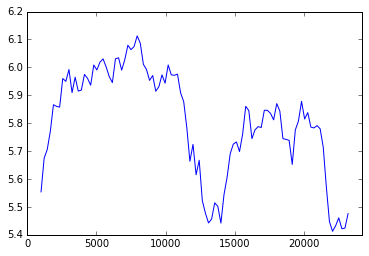

In [84]:
plt.plot(c,t)
plt.xlim([0,len(all_word_list_split)])

In [87]:
rated_scenes = [my_LabMT.score(dictify(listify(" ".join([line[0] for line in scene]))),stopVal=1.0) for act in data for scene in act]

In [88]:
rated_scenes

[5.216923076923077,
 5.637549800796816,
 6.014229249011856,
 6.229917012448132,
 5.838073394495417,
 6.044086956521739,
 5.835151515151515,
 5.831348314606742,
 6.114473684210524,
 6.0388209606986925,
 6.016800000000004,
 6.0902659574468085,
 6.125581395348838,
 5.651705426356589,
 5.616458333333332,
 5.5881420765027325,
 6.058807339449542,
 5.789036544850497,
 5.729580419580418,
 5.909684210526315,
 5.551920000000001,
 5.759215686274511,
 5.802617283950615,
 5.530388888888888,
 5.646538461538461,
 5.395729646697387]

In [93]:
scene_centers = [flat_scene_word_lengths[i]/2+sum(flat_scene_word_lengths[0:i]) for i in range(len(flat_scene_word_lengths))]

In [94]:
scene_centers

[53.0,
 1016.5,
 2321.5,
 3161.0,
 4065.5,
 5124.5,
 5780.5,
 6017.5,
 7002.5,
 8183.5,
 9372.0,
 10518.5,
 10998.5,
 11928.5,
 13275.5,
 14526.5,
 15363.5,
 16527.5,
 18058.0,
 18755.0,
 19171.0,
 19517.5,
 20179.5,
 21091.0,
 21564.0,
 22929.0]

(0, 24183)

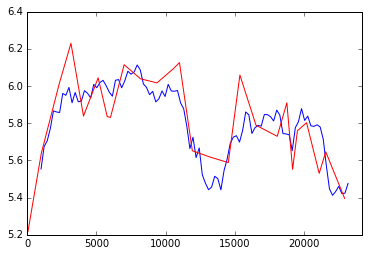

In [102]:
plt.plot(c,t,"b")
plt.plot(scene_centers,rated_scenes,"r")
plt.xlim([0,len(all_word_list_split)])

In [110]:
stopped_LabMT = LabMT(stopVal=1.0)

In [111]:
np.mean(stopped_LabMT.scorelist)

5.6237335834896811

In [112]:
np.median(stopped_LabMT.scorelist)

6.2599999999999998

(0, 24183)

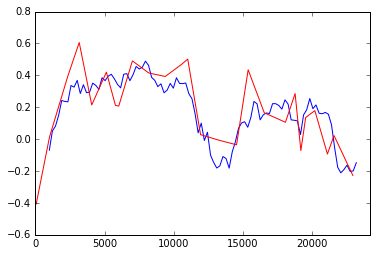

In [113]:
plt.plot(c,t-np.mean(stopped_LabMT.scorelist),"b")
plt.plot(scene_centers,rated_scenes-np.mean(stopped_LabMT.scorelist),"r")
plt.xlim([0,len(all_word_list_split)])

In [117]:
f = open("rj_annotations.txt","r")
f.readline()
responses = f.read().rstrip().split("\n\n")
f.close()

In [118]:
len(responses)

5

In [121]:
clean_response = list(map(lambda x: list(map(lambda y: y.split("\t"),x.split("\n"))),responses))

In [122]:
clean_response[0]

[['0',
  '0',
  '1',
  "The lover's deaths are foretold but a note of hope is struck in the final lines."],
 ['0',
  '1',
  '-1',
  'Initial comedy followed by the fight ends on a down note with Romeo professing his love for Rosaline.'],
 ['0',
  '2',
  '0',
  'Both Romeo and Juliet suffer from others attempting to influence their fate but no indication of their success or failure is given.'],
 ['0',
  '3',
  '4',
  'First appearance of the beauty of Juliet and the comic figure of the nurse.'],
 ['0',
  '4',
  '4',
  "Mercutio's Queen Mab speech lightens Romeo's protestations of love."],
 ['0',
  '5',
  '2',
  'The first meeting of Romeo and Juliet is tempered by the discovery that they are enemies and the foreshadowing of the tragedy to come.'],
 ['0', '6', '5', 'Description of love and desire between Romeo and Juliet.'],
 ['0', '7', '5', 'Romeo is clearly deeply in love with Juliet.'],
 ['0',
  '8',
  '5',
  'The balcony scene - one of the most famous declarations of love in classic 

In [123]:
user_arcs = [[int(x[2]) for x in y] for y in clean_response]

In [124]:
user_arcs[0]

[1,
 -1,
 0,
 4,
 4,
 2,
 5,
 5,
 5,
 4,
 5,
 5,
 5,
 -5,
 1,
 1,
 -1,
 -4,
 2,
 0,
 -2,
 -1,
 -3,
 -4,
 -4,
 1]

(0, 24183)

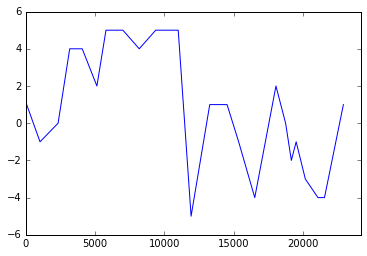

In [126]:
plt.plot(scene_centers,user_arcs[0])
plt.xlim([0,len(all_word_list_split)])

(0, 24183)

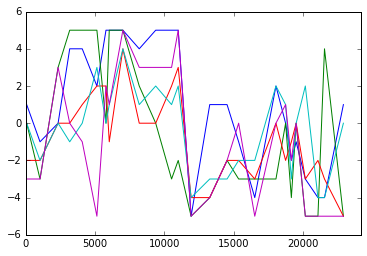

In [127]:
for arc in user_arcs:
    plt.plot(scene_centers,arc)
plt.xlim([0,len(all_word_list_split)])

(-1.1, 1.1)

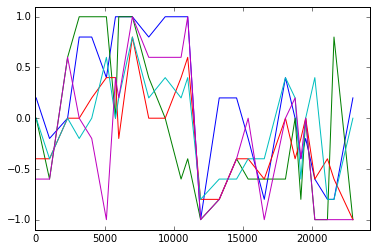

In [129]:
for arc in user_arcs:
    plt.plot(scene_centers,np.array(arc)/5)
plt.xlim([0,len(all_word_list_split)])
plt.ylim([-1.1,1.1])

In [130]:
arc_data = np.zeros((5,len(user_arcs[0])))

In [131]:
for i,arc in enumerate(user_arcs):
    arc_data[i,:] = np.array(arc)/5

In [132]:
np.mean(arc_data,axis=0)

array([-0.16, -0.44,  0.24,  0.32,  0.36,  0.28,  0.36,  0.44,  0.92,
        0.4 ,  0.4 ,  0.32,  0.52, -0.92, -0.56, -0.32, -0.32, -0.68,
        0.04,  0.  , -0.48, -0.04, -0.56, -0.8 , -0.48, -0.56])

(-1.1, 1.1)

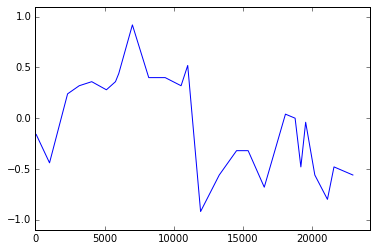

In [133]:
plt.plot(scene_centers,np.mean(arc_data,axis=0))
plt.xlim([0,len(all_word_list_split)])
plt.ylim([-1.1,1.1])

(0, 24183)

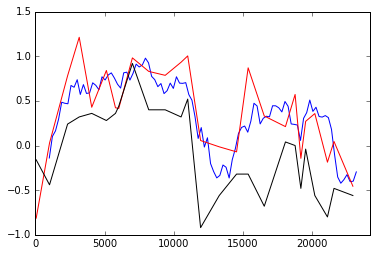

In [135]:
plt.plot(c,(t-np.mean(stopped_LabMT.scorelist))*2,"b")
plt.plot(scene_centers,(rated_scenes-np.mean(stopped_LabMT.scorelist))*2,"r")
plt.plot(scene_centers,np.mean(arc_data,axis=0),"k")
plt.xlim([0,len(all_word_list_split)])

(0, 24183)

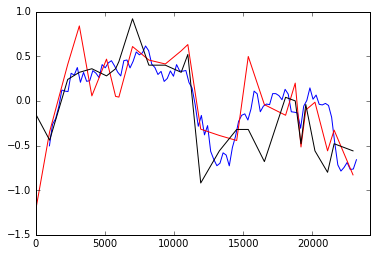

In [137]:
plt.plot(c,(t-np.mean(t))*2,"b")
plt.plot(scene_centers,(rated_scenes-np.mean(rated_scenes))*2,"r")
plt.plot(scene_centers,np.mean(arc_data,axis=0),"k")
plt.xlim([0,len(all_word_list_split)])

(0, 24183)

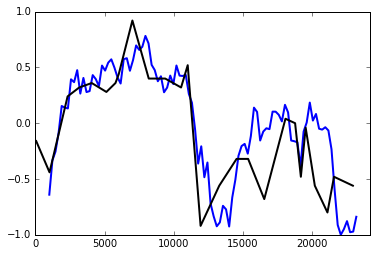

In [144]:
plt.plot(c,(t-np.mean(t))*(1/np.max(np.abs(t-np.mean(t)))),"b",linewidth=2)
plt.plot(scene_centers,np.mean(arc_data,axis=0),"k",linewidth=2)
plt.xlim([0,len(all_word_list_split)])

In [145]:
import matplotlib

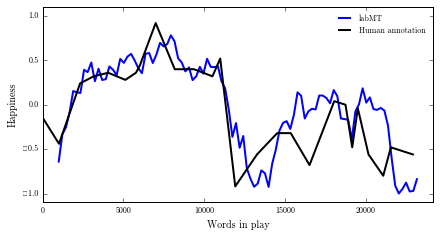

In [157]:
matplotlib.style.use("paper-twocol")
plt.plot(c,(t-np.mean(t))*(1/np.max(np.abs(t-np.mean(t)))),"b",linewidth=2)
plt.plot(scene_centers,np.mean(arc_data,axis=0),"k",linewidth=2)
plt.xlim([0,len(all_word_list_split)])
plt.ylim([-1.1,1.1])
plt.xlabel("Words in play")
plt.ylabel("Happiness")
plt.legend(["labMT","Human annotation"],loc="best")
plt.savefig("validation.png",dpi=600,bbox_inches="tight")
plt.savefig("validation.pdf",dpi=600,bbox_inches="tight")